# Equity Portfolio Optimization — BSE Small-Cap Stock Selection

**Project Type:** College Data Science Project  
**Dataset:** BSE small-cap financial fundamentals across two time periods (T1, T2)  
**Objective:** Predict stock prices at T2 using T1 fundamentals, then rank and select top 50 stocks using a composite scoring model.

### Pipeline Summary
- **Data:** Multi-source CSV merge across P&L, balance sheet, cash flow, and ratios
- **Feature Selection:** Mutual Information Regression (top 75th percentile)
- **Models:** XGBoost Regressor, Gradient Boosting Regressor (sklearn Pipeline)
- **Stock Ranking:** Composite score = 0.4 × Predicted Return + 0.3 × ROE + 0.2 × ROA + 0.1 × P/E
- **Risk Classification:** Rule-based (Low / Medium / High) using Debt-to-Equity, P/E, ROE
- **Output:** Top 50 stocks with equal-weight ₹10L portfolio allocation

## 1. Imports and Setup

In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data Loading — T1 (Training Period)

> **Note:** Data was loaded from Google Drive during development. Replace these paths with local paths or your own Drive mount to reproduce results.

In [188]:
# File paths for T1 data components
# These paths correspond to the location of CSV files containing various financial data for timestamp T1.

# Annual profit and loss data - Part 1
t1_annual_p_l_1='/content/drive/MyDrive/Financial Forensics Project/T1_data/Annual_P_L_1.csv'

# Annual profit and loss data - Part 2
t1_annual_p_l_2='/content/drive/MyDrive/Financial Forensics Project/T1_data/Annual_P_L_2.csv'

# Balance sheet data providing a snapshot of financial position at T1
t1_balance_sheet='/content/drive/MyDrive/Financial Forensics Project/T1_data/Balance_Sheet.csv'

# Quarterly profit and loss data - Part 1
t1_quarter_p_l_1='/content/drive/MyDrive/Financial Forensics Project/T1_data/Quarter_P_L_1.csv'

# Quarterly profit and loss data - Part 2
t1_quarter_p_l_2='/content/drive/MyDrive/Financial Forensics Project/T1_data/Quarter_P_L_2.csv'

# Cash flow statement detailing cash inflows and outflows at T1
t1_cash_flow_statement='/content/drive/MyDrive/Financial Forensics Project/T1_data/cash_flow_statments.csv'

# Additional metrics relevant for financial analysis at T1
t1_other_metrics='/content/drive/MyDrive/Financial Forensics Project/T1_data/other_metrics.csv'

# Stock price data for companies at T1
t1_price='/content/drive/MyDrive/Financial Forensics Project/T1_data/price.csv'

# Financial ratios - Part 1
t1_ratios_1='/content/drive/MyDrive/Financial Forensics Project/T1_data/ratios_1.csv'

# Financial ratios - Part 2
t1_ratios_2='/content/drive/MyDrive/Financial Forensics Project/T1_data/ratios_2.csv'

In [189]:
# Creating a list of DataFrames for T1 data
# This list consolidates all the loaded DataFrames corresponding to T1 financial data.

t1_df_list = [
    t1_annual_p_l_1,          # Annual Profit and Loss Data - Part 1
    t1_annual_p_l_2,          # Annual Profit and Loss Data - Part 2
    t1_balance_sheet,         # Balance Sheet Data
    t1_quarter_p_l_2,         # Quarterly Profit and Loss Data - Part 2
    t1_cash_flow_statement,   # Cash Flow Statement Data
    t1_other_metrics,         # Other Metrics Data
    t1_price,                 # Stock Price Data
    t1_ratios_1,              # Financial Ratios Data - Part 1
    t1_ratios_2               # Financial Ratios Data - Part 2
]

In [ ]:
# Merge all T1 DataFrames iteratively on 'Name' column using inner join
# Inner join ensures only stocks present in all data sources are kept
def merge_df(df_link_list):
    """
    Merges multiple DataFrames from a list of CSV file paths into a single DataFrame.
    The merging is performed iteratively using an inner join on the 'Name' column.

    Parameters:
    - df_link_list (list): List of file paths (strings) to the CSV files to be merged.

    Returns:
    - merged_df (DataFrame): The final merged DataFrame containing all unique columns from the input files.
    """

    df_list = []  # Initialize an empty list to store DataFrames.

    # Read each CSV file from the provided links and append to the df_list.
    for link in df_link_list:
        df = pd.read_csv(link)  # Load the CSV file into a DataFrame.
        df_list.append(df)      # Append the DataFrame to the list.

    merged_df = None  # Initialize the merged DataFrame.

    # Iterate through the list of DataFrames to merge them.
    for i in range(len(df_list)):
        df = df_list[i]  # Get the current DataFrame from the list.
        if merged_df is None:
            # Set the first DataFrame as the base for merging.
            merged_df = df
        else:
            # Identify columns that are not already in the merged DataFrame.
            unique_cols = [col for col in df.columns if col not in merged_df.columns or col == 'Name']

            # Perform an inner join on the 'Name' column.
            merged_df = pd.merge(merged_df, df[unique_cols], on='Name')

    return merged_df  # Return the final merged DataFrame.


In [191]:
t1_merged_df=merge_df(t1_df_list)

In [192]:
t1_merged_df_copy = t1_merged_df.copy()

In [193]:
t1_merged_df_copy.columns[t1_merged_df_copy.columns.duplicated()]

Index([], dtype='object')

In [194]:
t1_merged_df.head()

,Name,BSE Code,NSE Code,Industry,Current Price,Sales,OPM,Profit after tax,Return on capital employed,EPS,...,Historical PE 10Years,Historical PE 7Years,Historical PE 5Years,Market Capitalization 3years back,Market Capitalization 5years back,Market Capitalization 7years back,Market Capitalization 10years back,Average Working Capital Days 3years,Change in FII holding 3Years,Change in DII holding 3Years
0,20 Microns,533022.0,20MICRONS,Mining / Minerals / Metals,224.55,777.49,13.59,57.38,21.70,15.89,...,9.12,8.38,8.23,124.03,134.79,123.50,105.34,84.01,0.70,0.00
1,21st Cent. Mgmt.,526921.0,21STCENMGM,Finance & Investments,70.44,34.92,94.27,32.23,73.00,30.70,...,2.43,3.57,4.69,14.65,20.21,19.16,4.25,51.05,-0.35,-0.15
2,360 ONE,542772.0,360ONE,Finance & Investments,1009.40,2920.91,58.37,804.18,14.47,22.41,...,29.05,29.05,29.05,10894.33,NaN,NaN,NaN,-109.10,38.31,6.97
3,3B Blackbio,532067.0,NaN,Healthcare,1182.00,74.12,44.50,32.10,20.95,38.13,...,15.49,13.15,10.69,213.76,48.38,22.11,4.79,210.92,1.50,1.80
4,3C IT Solutions,544190.0,NaN,Computers - Software - Medium / Small,44.01,61.93,5.17,1.14,25.63,31.67,...,1.51,1.51,1.51,NaN,NaN,NaN,NaN,64.30,NaN,NaN


In [195]:
missing_values = t1_merged_df.isna().sum()
missing_percentage = (missing_values / len(t1_merged_df)) * 100

# Show features with missing data
missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
missing_data = missing_data[missing_data['Percentage'] <= 10]
print(missing_data)

                                     Missing Values  Percentage
Name                                              0    0.000000
BSE Code                                        464    9.937888
Industry                                          0    0.000000
Current Price                                     1    0.021418
Sales                                             4    0.085671
...                                             ...         ...
Return on assets 3years                         219    4.690512
Historical PE 10Years                           182    3.898051
Historical PE 7Years                            255    5.461555
Historical PE 5Years                            339    7.260655
Average Working Capital Days 3years               0    0.000000

[222 rows x 2 columns]


## 3. Data Loading — T2 (Evaluation Period)

> **Note:** Data was loaded from Google Drive during development. Replace these paths with local paths or your own Drive mount to reproduce results.

In [196]:
# Links to the CSV files containing the financial data for T2.

# Annual Profit & Loss statements for T2 (split into two parts).
t2_annual_p_l_1 = '/content/drive/MyDrive/Financial Forensics Project/T2_data/Annual_P_L_1.csv'
t2_annual_p_l_2 = '/content/drive/MyDrive/Financial Forensics Project/T2_data/Annual_P_L_2.csv'

# Balance sheet data for T2.
t2_balance_sheet = '/content/drive/MyDrive/Financial Forensics Project/T2_data/Balance_Sheet.csv'

# Quarterly Profit & Loss statements for T2 (split into two parts).
t2_quarter_p_l_1 = '/content/drive/MyDrive/Financial Forensics Project/T2_data/Quarter_P_L_1.csv'
t2_quarter_p_l_2 = '/content/drive/MyDrive/Financial Forensics Project/T2_data/Quarter_P_L_2.csv'

# Cash flow statement for T2.
t2_cash_flow_statement = '/content/drive/MyDrive/Financial Forensics Project/T2_data/cash_flow_statements.csv'

# Other metrics for T2.
t2_other_metrics = '/content/drive/MyDrive/Financial Forensics Project/T2_data/other_metrics.csv'

# Price data for T2 (stocks or company valuation).
t2_price = '/content/drive/MyDrive/Financial Forensics Project/T2_data/price.csv'

# Financial ratios data for T2 (split into two parts).
t2_ratios_1 = '/content/drive/MyDrive/Financial Forensics Project/T2_data/ratios_1.csv'
t2_ratios_2 = '/content/drive/MyDrive/Financial Forensics Project/T2_data/ratios_2.csv'

In [197]:
# List of links to the CSV files containing the financial data for T2.

t2_df_list = [
    t2_annual_p_l_1,          # Annual Profit & Loss Statement Part 1.
    t2_annual_p_l_2,          # Annual Profit & Loss Statement Part 2.
    t2_balance_sheet,         # Balance Sheet Data.
    t2_quarter_p_l_2,         # Quarterly Profit & Loss Statement Part 2.
    t2_cash_flow_statement,   # Cash Flow Statement Data.
    t2_other_metrics,         # Additional Financial Metrics.
    t2_price,                 # Price Data (Stock/Valuation).
    t2_ratios_1,              # Financial Ratios Part 1.
    t2_ratios_2               # Financial Ratios Part 2.
]

In [198]:
t2_merged_df=merge_df(t2_df_list)

## 4. Data Merging and Preprocessing

In [199]:
columns_df1 = set(t1_merged_df.columns)
columns_df2 = set(t2_merged_df.columns)

# Uncommon columns
uncommon_cols = columns_df1.symmetric_difference(columns_df2)
print("Uncommon columns:", uncommon_cols)

Uncommon columns: {'YOY Quarterly sales growth', 'Sales latest quarter', 'Operating profit preceding quarter', 'Net Profit latest quarter', 'YOY Quarterly profit growth'}


In [200]:
#Selecting common coloumns between t1 and t2
common_columns = t1_merged_df.columns.intersection(t2_merged_df.columns)


In [201]:
t1_merged_df=t1_merged_df[common_columns]
t2_merged_df=t2_merged_df[common_columns]

In [202]:
#Removing coloumns where current price is not present
t1_merged_df = t1_merged_df[t1_merged_df['Current Price'].notna()]
t2_merged_df = t2_merged_df[t2_merged_df['Current Price'].notna()]

In [203]:
t1_merged_df.shape

(4668, 316)

In [204]:
from sklearn.model_selection import train_test_split

In [206]:
drop_columns = [
    'Current Price',                # Target variable to be predicted
    "Name",                         # Likely an identifier, not useful for prediction
    "BSE Code",                     # Not needed for prediction
    "NSE Code",                     # Not needed for prediction
    "Credit rating",
    'Industry'
]

In [207]:
#Splitting data into train and test
X_train, X_test, y_train, y_test = train_test_split(t1_merged_df.drop(drop_columns, axis=1), t1_merged_df['Current Price'], test_size=0.2, random_state=42)

In [208]:
#Splitting t2 data in train and test
X_t2,y_t2=t2_merged_df.drop(drop_columns, axis=1),t2_merged_df['Current Price']

## 5. Feature Selection (Mutual Information)

In [209]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_regression, SelectPercentile
from sklearn.metrics import r2_score

In [ ]:
# Preprocessor: apply median imputation to all numeric columns
# Industry column was dropped in drop_columns, so OHE is not needed
other_columns = X_train.columns

preprocessor = ColumnTransformer([
    ('si_imputer', SimpleImputer(strategy='median'), other_columns),  # Impute missing values with column median
], remainder='passthrough')


In [ ]:
# Use mutual information to measure non-linear dependency between each feature and target price
# SelectPercentile keeps only the top 75% most informative features
sp = SelectPercentile(score_func=mutual_info_regression, percentile=75)


In [213]:
from sklearn.feature_selection import mutual_info_regression

In [214]:
# Compute mutual information scores for each feature in the dataset
# 'mutual_info_regression' calculates the dependency of each feature with the target variable (y_train)

# First, handle missing values in X_train using median imputation
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_train_imputed_df = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)

mi = mutual_info_regression(X_train_imputed_df, y_train)

# Create a DataFrame to store feature names and their mutual information scores
mi_df = pd.DataFrame({
    'features': X_train.columns,  # List of feature names
    'mi_scores': mi                   # Corresponding MI scores
})

# Sort the DataFrame by mutual information scores in descending order
# This ranks the features by their relevance to the target variable
mi_df = mi_df.sort_values(by='mi_scores', ascending=False)

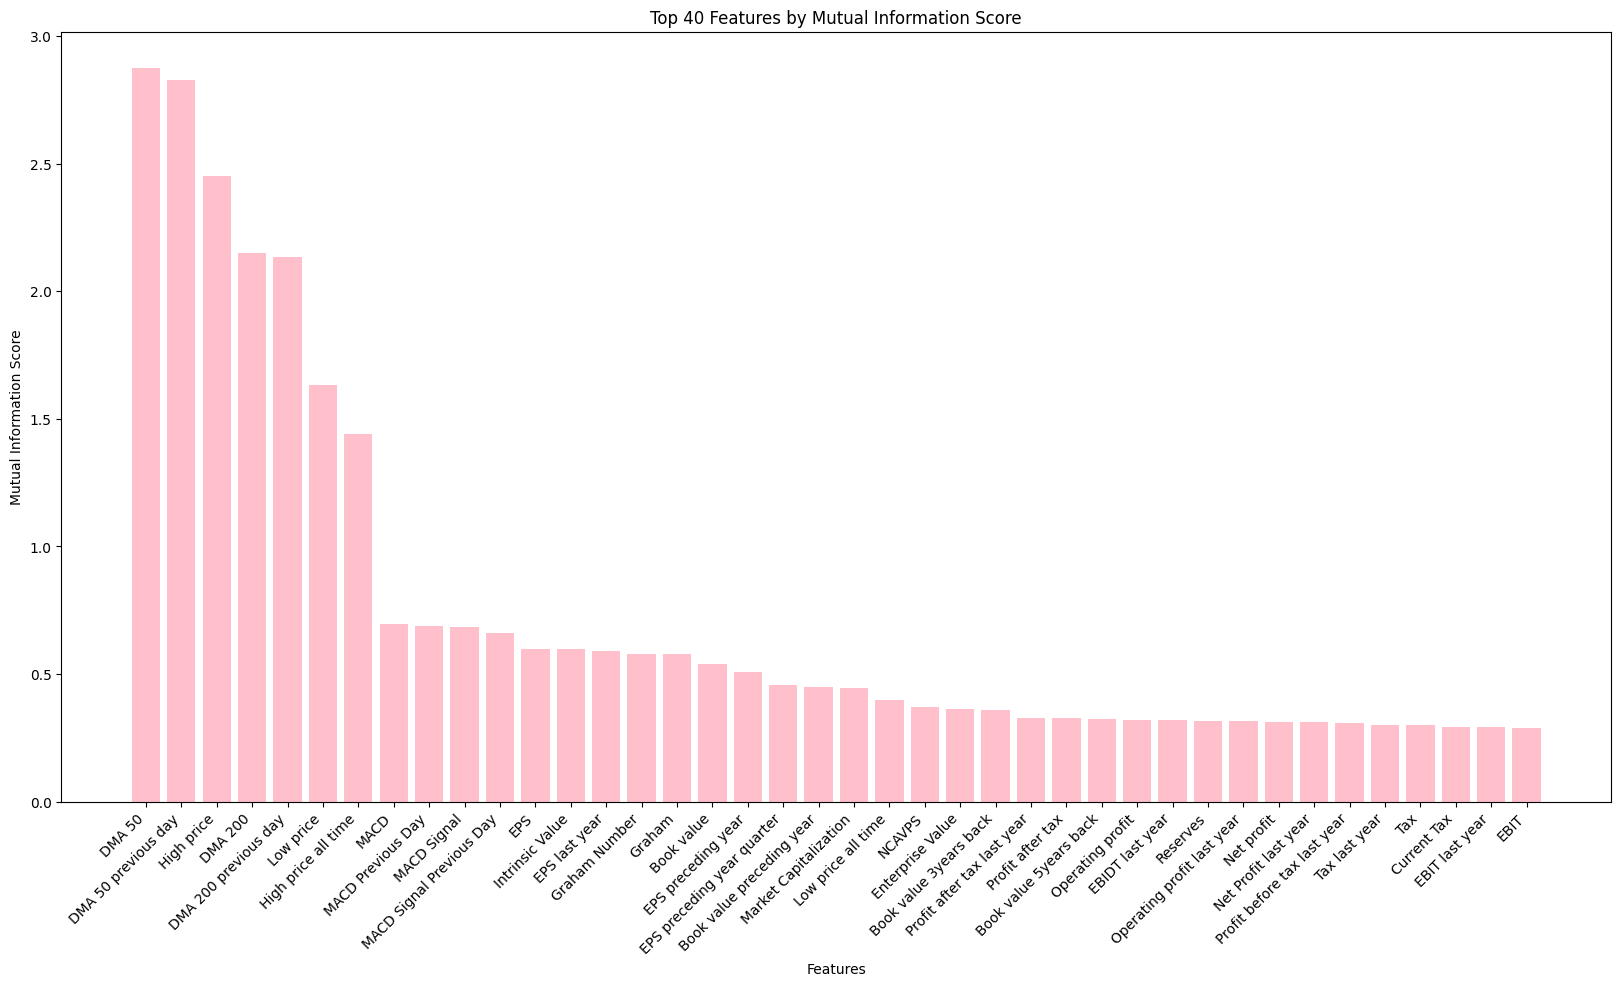

In [215]:
# Select the top 40 features based on their mutual information scores
top_features = mi_df.nlargest(40, 'mi_scores')

# Create a bar plot to visualize the top 40 features and their corresponding mutual information scores
plt.figure(figsize=(20, 10))  # Set the figure size for better readability
plt.bar(top_features.features, top_features.mi_scores, color='pink')  # Create a bar chart with pink bars

# Rotate x-axis labels for better visibility and align them to the right
plt.xticks(rotation=45, ha='right')

# Add axis labels for clarity
plt.xlabel('Features')  # Label for the x-axis
plt.ylabel('Mutual Information Score')  # Label for the y-axis

# Add a descriptive title to the plot
plt.title('Top 40 Features by Mutual Information Score')

# Display the bar chart
plt.show()

## 6. Model Training — XGBoost

In [216]:
from xgboost import XGBRegressor

In [ ]:
# Tuned hyperparameters — reg_lambda and reg_alpha add L2/L1 regularization to reduce overfitting
# max_depth=4 and max_leaves=10 keep trees shallow to avoid memorizing training data
best_params_xgb = {
    'random_state': 42,
    'n_estimators': 300,
    'max_leaves': 10,
    'max_depth': 4,
    'reg_lambda': 5,       # L2 regularization
    'learning_rate': 0.2,
    'reg_alpha': 0.1       # L1 regularization
}


In [219]:
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),  # Preprocessing for imputation and encoding
    ('sp', sp),                      # Feature selection using Mutual Information
    ('model', XGBRegressor(**best_params_xgb))  # XGBoost model with custom parameters
])

> **Fix:** The original `preprocessor` was configured with `OneHotEncoder` on `'Industry'`, but `Industry` was dropped from `drop_columns`. This caused a `KeyError` at fit time. The cell below resets the preprocessor to imputation-only and fits the XGBoost pipeline.

In [220]:
# Reset preprocessor: use imputation-only since 'Industry' column was dropped
numeric_cols_in_X_train = X_train.columns
fixed_preprocessor = ColumnTransformer(
    [('si_imputer', SimpleImputer(strategy='median'), numeric_cols_in_X_train)],
    remainder='passthrough'
)

# Update xgb_pipe and fit
xgb_pipe.steps[0] = ('preprocessor', fixed_preprocessor)
xgb_pipe.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('si_imputer',
                                                  SimpleImputer(strategy='median'),
                                                  Index(['Sales', 'OPM', 'Profit after tax', 'Return on capital employed', 'EPS',
       'Change in promoter holding', 'Sales last year',
       'Operating profit last year', 'Other income last year',
       'EBIDT last year',
       ...
       'Historical PE 10Years', 'Historical PE 7...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.2,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=10, min_child_weight=None,
                              missing=nan, monotone_constraints=None,
                              multi_strategy=None, n_estimators=300,
                              n_jobs=None, num_parallel_tree=None, ...))])

In [221]:
# Predict the target variable for the training dataset using the trained pipeline
y_pred_xgb_train = xgb_pipe.predict(X_train)

# Calculate the R² score for the training predictions
r2_xgb_train = r2_score(y_pred_xgb_train, y_train)

# Display the R² score for the training dataset
print(f"R² Score (XGBoost - Training Data): {r2_xgb_train:.4f}")

R² Score (XGBoost - Training Data): 1.0000


In [222]:
y_pred_xgb_test = xgb_pipe.predict(X_test)
r2_xgb_test=r2_score(y_pred_xgb_test,y_test.fillna(0))
print(f"R² Score (XGBoost - Test Data): {r2_xgb_test:.4f}")

R² Score (XGBoost - Test Data): 0.8911


In [223]:
y_pred_xgb_t2 = xgb_pipe.predict(X_t2)
r2_xgb_t2=r2_score(y_pred_xgb_t2,y_t2.fillna(0))
print(f"R² Score (XGBoost - T2 Data): {r2_xgb_t2:.4f}")

R² Score (XGBoost - T2 Data): 0.6494


## 7. Model Training — Gradient Boosting

In [224]:
from sklearn.ensemble import GradientBoostingRegressor

In [225]:
          # Learning rate for boosting
gb_pipe = Pipeline([
    ('preprocessor', preprocessor),  # Impute missing values and encode categorical features
    ('sp', sp),                      # Select top features based on Mutual Information scores
    ('model', GradientBoostingRegressor(
        loss='squared_error',        # Use squared error as the loss function
        learning_rate=0.1,           # Learning rate for boosting
        n_estimators=300,            # Number of boosting iterations
        random_state=42              # Ensure reproducibility
    ))
])

> **Fix:** Same `KeyError: 'Industry'` issue as XGBoost. The cell below replaces the preprocessor in `gb_pipe` with imputation-only and fits.

In [226]:
# Reset preprocessor for gb_pipe: imputation-only since 'Industry' was dropped
numeric_cols_in_X_train_gb = X_train.columns
fixed_preprocessor_gb = ColumnTransformer(
    [('si_imputer', SimpleImputer(strategy='median'), numeric_cols_in_X_train_gb)],
    remainder='passthrough'
)

# Update gb_pipe and fit
gb_pipe.steps[0] = ('preprocessor', fixed_preprocessor_gb)
gb_pipe.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('si_imputer',
                                                  SimpleImputer(strategy='median'),
                                                  Index(['Sales', 'OPM', 'Profit after tax', 'Return on capital employed', 'EPS',
       'Change in promoter holding', 'Sales last year',
       'Operating profit last year', 'Other income last year',
       'EBIDT last year',
       ...
       'Historical PE 10Years', 'Historical PE 7...
       'Market Capitalization 7years back',
       'Market Capitalization 10years back',
       'Average Working Capital Days 3years', 'Change in FII holding 3Years',
       'Change in DII holding 3Years'],
      dtype='object', length=310))])),
                ('sp',
                 SelectPercentile(percentile=75,
                                  score_func=<function mutual_info_regression at 0x7b794ee2a0c0>)),
                ('model',
                 GradientBoostingRegressor(n_estimators=300, random_state=42))])

In [227]:
# Predict the target variable for the training dataset using the trained pipeline
y_pred_gb_train = gb_pipe.predict(X_train)

# Calculate the R² score for the training predictions
r2_gb_train = r2_score(y_pred_gb_train, y_train)

# Display the R² score for the training dataset
print(f"R² Score (XGBoost - Training Data): {r2_gb_train:.4f}")

R² Score (XGBoost - Training Data): 1.0000


In [228]:
#Testing on Validation set
y_pred_gb_test = gb_pipe.predict(X_test)
r2_gb_test=r2_score(y_pred_gb_test,y_test.fillna(0))
print(f"R² Score (XGBoost - Test Data): {r2_gb_test:.4f}")

R² Score (XGBoost - Test Data): 0.9964


In [229]:
#Testing on T2 data
y_pred_gb_t2 = gb_pipe.predict(X_t2)
r2_gb_t2=r2_score(y_pred_gb_t2,y_t2.fillna(0))
print(f"R² Score (XGBoost - T2 Data): {r2_gb_t2:.4f}")

R² Score (XGBoost - T2 Data): 0.9767


## 8. Model Evaluation (R² Scores)

R² scores were computed above for both models on Training, Validation (Test), and T2 (held-out) sets. The Gradient Boosting Regressor was selected as the final model for stock price prediction.

## 9. Stock Filtering and Risk Classification

In [230]:
#Saving the predicted price in t2 dataset
t2_merged_df['Predicted Price'] = y_pred_gb_t2

In [231]:
#Mergeing t1 current price in t2 dataset
t2_merged_df = pd.merge(t2_merged_df, t1_merged_df_copy[['Name','Current Price']], on='Name')

In [232]:
t2_merged_df

,Name,BSE Code,NSE Code,Industry,Current Price_x,Sales,OPM,Profit after tax,Return on capital employed,EPS,...,Historical PE 5Years,Market Capitalization 3years back,Market Capitalization 5years back,Market Capitalization 7years back,Market Capitalization 10years back,Average Working Capital Days 3years,Change in FII holding 3Years,Change in DII holding 3Years,Predicted Price,Current Price_y
0,20 Microns,533022.0,20MICRONS,Mining / Minerals / Metals,287.75,817.48,13.30,60.12,21.70,16.72,...,8.39,124.03,134.79,123.50,105.34,84.01,0.75,0.06,280.159856,224.55
1,21st Cent. Mgmt.,526921.0,21STCENMGM,Finance & Investments,86.30,146.13,42.95,59.40,78.43,56.57,...,2.09,14.65,20.21,19.16,4.25,172.84,-0.35,-0.15,83.375671,70.44
2,360 ONE,542772.0,360ONE,Finance & Investments,1056.30,2831.50,55.18,926.34,14.47,24.04,...,29.31,10894.33,NaN,NaN,NaN,-109.10,39.65,7.35,1125.908490,1009.40
3,3B Blackbio,532067.0,NaN,Healthcare,1245.65,74.12,44.50,32.10,20.95,38.13,...,10.86,213.76,48.38,22.11,4.79,210.92,1.81,1.87,1085.177480,1182.00
4,3C IT Solutions,544190.0,NaN,Computers - Software - Medium / Small,39.30,29.84,7.44,0.12,9.60,0.28,...,132.14,NaN,NaN,NaN,NaN,122.43,NaN,NaN,42.241698,44.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4608,Zota Health Care,NaN,ZOTA,Trading,690.75,180.49,4.18,-14.35,-7.32,-5.55,...,133.91,340.16,456.33,NaN,NaN,129.70,0.01,0.00,708.277774,571.75
4609,Zuari Agro Chem.,534742.0,ZUARI,Fertilizers,221.91,4486.73,7.82,133.24,11.13,31.68,...,4.38,382.31,781.23,1529.44,538.34,26.92,0.18,-2.02,189.005479,227.50
4610,Zuari Industries,500780.0,ZUARIIND,Sugar,373.95,837.80,6.19,-0.71,4.98,239.72,...,25.55,236.67,318.11,374.26,221.97,262.15,0.36,-3.42,403.971159,398.00
4611,Zydus Lifesci.,532321.0,ZYDUSLIFE,Pharmaceuticals - Indian - Bulk Drugs & Formln,1249.90,19547.40,27.54,3860.03,22.34,38.36,...,22.98,45136.81,35528.99,45249.42,20984.83,103.20,0.94,2.06,1267.523728,1070.05


In [233]:
#Calculating predicted rate of return
t2_merged_df['Predicted rate of return'] = (t2_merged_df['Predicted Price'] - t2_merged_df['Current Price_y']) / t2_merged_df['Current Price_y']

In [234]:
#Converting it into percentage
t2_merged_df['Predicted rate of return'] = t2_merged_df['Predicted rate of return'] * 100

In [235]:
#Creating another dataframe with return rate > 0
project_df = t2_merged_df[t2_merged_df['Predicted rate of return']>0]

In [ ]:
# Rule-based classifier using fundamental thresholds
# Low risk: low debt, reasonable P/E (not overvalued), strong ROE
def classify_risk(row):
    if row["Debt to equity"] < 0.5 and 10 <= row["Price to Earning"] <= 25 and row["Return on equity"] > 15:
        return "Low Risk"
    elif 0.5 <= row["Debt to equity"] <= 1.5 and 25 <= row["Price to Earning"] <= 50 and 10 <= row["Return on equity"] <= 15:
        return "Medium Risk"
    else:
        return "High Risk"


In [237]:
project_df['Risk Level'] = project_df.apply(classify_risk, axis=1)

/tmp/ipykernel_9615/2728636457.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  project_df['Risk Level'] = project_df.apply(classify_risk, axis=1)


In [238]:
#Sorting in descending value
project_df = project_df.sort_values(by='Predicted rate of return', ascending=False)
project_df

,Name,BSE Code,NSE Code,Industry,Current Price_x,Sales,OPM,Profit after tax,Return on capital employed,EPS,...,Market Capitalization 5years back,Market Capitalization 7years back,Market Capitalization 10years back,Average Working Capital Days 3years,Change in FII holding 3Years,Change in DII holding 3Years,Predicted Price,Current Price_y,Predicted rate of return,Risk Level
1994,K-Lifestyle,514221.0,NaN,Textiles - Products,0.37,2.70,15.19,-56.75,-5.85,-0.56,...,20.45,27.60,106.33,-8586.18,NaN,NaN,6.051234,0.33,1733.707127,High Risk
4008,Sword-Edge Comm.,512359.0,NaN,Trading,0.34,1.04,57.69,0.59,-1.03,0.03,...,1.52,7.81,17.14,13568.48,0.00,0.00,3.950056,0.33,1096.986516,High Risk
4212,Triton Corp.,523387.0,NaN,Computers - Software - Medium / Small,0.54,0.00,NaN,-0.44,-12.85,-0.02,...,3.80,7.00,5.00,0.00,0.00,-0.10,5.816065,0.52,1018.474109,High Risk
4477,VKJ Infradevelop,536128.0,NaN,Construction,0.52,0.00,NaN,0.02,0.07,0.00,...,161.13,98.29,NaN,0.00,0.00,0.00,4.192126,0.46,811.331659,High Risk
3083,Procal Electroni,526009.0,NaN,Electronics - Components,0.63,0.00,NaN,-0.05,-1.28,-0.14,...,0.23,0.21,0.66,0.00,0.00,0.00,5.491703,0.63,771.698840,High Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
876,CRISIL,500092.0,CRISIL,Miscellaneous,4311.35,3188.64,26.95,649.94,41.36,88.89,...,11636.24,15715.19,8484.35,-1.77,0.36,0.20,4378.634475,4377.25,0.031629,High Risk
49,Abbott India,500488.0,ABBOTINDIA,Pharmaceuticals - Multinational,28227.70,5848.91,24.84,1201.10,46.02,565.30,...,15522.19,9865.20,3729.78,-6.89,-0.07,2.07,27690.057782,27686.00,0.014656,High Risk
3263,Relaxo Footwear,530517.0,RELAXO,Leather / Leather Products,843.65,2923.43,13.61,188.52,13.63,7.57,...,9561.28,5993.08,1765.92,77.02,-0.13,2.20,831.721593,831.65,0.008609,High Risk
3587,Shanthi Gears,522034.0,SHANTIGEAR,Engineering,620.95,553.42,19.40,85.79,33.47,11.18,...,1055.77,909.09,541.78,86.34,-1.27,-0.51,628.985191,628.95,0.005595,High Risk


In [239]:
project_df[project_df['Risk Level']=='Low Risk']

,Name,BSE Code,NSE Code,Industry,Current Price_x,Sales,OPM,Profit after tax,Return on capital employed,EPS,...,Market Capitalization 5years back,Market Capitalization 7years back,Market Capitalization 10years back,Average Working Capital Days 3years,Change in FII holding 3Years,Change in DII holding 3Years,Predicted Price,Current Price_y,Predicted rate of return,Risk Level
3524,Seacoast Ship.,542753.0,NaN,Shipping,6.44,374.16,9.39,20.29,28.33,0.38,...,NaN,NaN,NaN,143.53,-1.41,0.00,15.393609,4.95,210.981998,Low Risk
346,Ashika Credit,543766.0,NaN,Finance & Investments,177.75,32.02,82.26,20.92,17.92,17.61,...,32.66,20.08,45.64,-9.62,-2.75,0.00,176.880033,83.79,111.099216,Low Risk
1537,Haria Apparels,538081.0,NaN,Textiles - Products,5.94,0.00,NaN,0.89,18.77,0.58,...,1.99,4.20,NaN,-2970.59,0.00,0.00,8.849337,5.25,68.558792,Low Risk
2067,Kellton Tech,519602.0,KELLTONTEC,Computers - Software - Medium / Small,155.52,995.79,10.90,68.53,16.17,7.06,...,385.05,627.57,31.52,167.27,-0.11,-0.30,178.377288,106.80,67.019932,Low Risk
1083,Edvenswa Enter,517170.0,NaN,Computers - Software - Medium / Small,95.89,84.29,13.68,7.38,23.81,3.90,...,5.04,3.62,3.22,125.40,0.36,0.00,96.608263,58.20,65.993579,Low Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1949,JMJ Fintech,538834.0,NaN,Finance & Investments,21.31,7.46,65.55,2.14,29.88,1.73,...,6.45,378.70,NaN,516.02,0.00,0.00,20.679803,20.50,0.877088,Low Risk
2198,L G Balakrishnan,500250.0,LGBBROSLTD,Auto Ancillaries,1361.45,2378.73,16.83,268.67,22.74,89.55,...,1203.58,975.06,317.52,53.30,4.14,0.68,1456.281882,1446.20,0.697129,Low Risk
1321,Garg Furnace,530615.0,NaN,Steel - Medium / Small,294.80,258.61,2.68,6.60,15.17,15.04,...,5.29,3.82,7.58,14.52,0.00,0.00,283.748963,282.25,0.531076,Low Risk
1412,Godfrey Phillips,500163.0,GODFRYPHLP,Cigarettes,4183.15,4419.59,20.19,883.04,22.62,169.84,...,6026.61,5891.43,3333.46,50.07,0.57,0.23,4273.902635,4262.00,0.279273,Low Risk


In [240]:
project_df_1 = project_df.copy()

In [241]:
#Calculating real rate of return
project_df['Real rate of return'] = (t2_merged_df['Current Price_x'] - t2_merged_df['Current Price_y']) / t2_merged_df['Current Price_y']

In [242]:
project_df['Real rate of return'] = project_df['Real rate of return'] * 100

In [243]:
project_df = project_df[project_df['Real rate of return']>0]

In [244]:
#Filtering out stocks with rate of return > 150
project_df_11 = project_df[project_df['Predicted rate of return']<=150]

In [245]:
project_df[project_df['Predicted rate of return']>=150]

,Name,BSE Code,NSE Code,Industry,Current Price_x,Sales,OPM,Profit after tax,Return on capital employed,EPS,...,Market Capitalization 7years back,Market Capitalization 10years back,Average Working Capital Days 3years,Change in FII holding 3Years,Change in DII holding 3Years,Predicted Price,Current Price_y,Predicted rate of return,Risk Level,Real rate of return
1994,K-Lifestyle,514221.0,NaN,Textiles - Products,0.37,2.70,15.19,-56.75,-5.85,-0.56,...,27.60,106.33,-8586.18,NaN,NaN,6.051234,0.33,1733.707127,High Risk,12.121212
4008,Sword-Edge Comm.,512359.0,NaN,Trading,0.34,1.04,57.69,0.59,-1.03,0.03,...,7.81,17.14,13568.48,0.00,0.00,3.950056,0.33,1096.986516,High Risk,3.030303
4212,Triton Corp.,523387.0,NaN,Computers - Software - Medium / Small,0.54,0.00,NaN,-0.44,-12.85,-0.02,...,7.00,5.00,0.00,0.00,-0.10,5.816065,0.52,1018.474109,High Risk,3.846154
4477,VKJ Infradevelop,536128.0,NaN,Construction,0.52,0.00,NaN,0.02,0.07,0.00,...,98.29,NaN,0.00,0.00,0.00,4.192126,0.46,811.331659,High Risk,13.043478
784,Cistro Telelink,531775.0,NaN,Trading,0.67,0.24,-29.17,0.02,0.54,-0.28,...,1.03,0.36,-447.12,0.00,0.00,5.558115,0.64,768.455403,High Risk,4.687500
1188,Excel Realty,533090.0,EXCEL,Construction,0.84,2.42,-95.04,1.36,0.68,0.01,...,114.21,63.45,5732.26,0.00,0.00,5.024851,0.71,607.725541,High Risk,18.309859
4205,Tridev Infra.,531568.0,NaN,Finance & Investments,7.06,0.19,-31.58,0.58,2.68,0.89,...,2.56,2.69,16.74,0.00,0.00,18.630356,2.86,551.411052,High Risk,146.853147
3735,Siti Networks,532795.0,SITINET,Entertainment / Electronic Media Software,0.88,1294.31,4.03,-292.18,-49.90,-3.42,...,2815.25,1051.39,-164.99,-10.26,2.43,4.162263,0.65,540.348084,High Risk,35.384615
502,Baron Infotech,532336.0,NaN,Computers - Software - Medium / Small,0.92,0.00,NaN,-0.17,-7.55,-0.17,...,0.49,1.53,-2689.70,0.00,0.00,5.491703,0.88,524.057124,High Risk,4.545455
3656,Shree Securities,538975.0,NaN,Finance & Investments,0.37,0.71,-1908.45,-13.55,-82.93,-0.74,...,NaN,NaN,-235.61,0.00,0.00,1.997353,0.36,454.820381,High Risk,2.777778


In [246]:
project_df_11.head(10)

,Name,BSE Code,NSE Code,Industry,Current Price_x,Sales,OPM,Profit after tax,Return on capital employed,EPS,...,Market Capitalization 7years back,Market Capitalization 10years back,Average Working Capital Days 3years,Change in FII holding 3Years,Change in DII holding 3Years,Predicted Price,Current Price_y,Predicted rate of return,Risk Level,Real rate of return
1234,Flexituff Vent.,533638.0,FLEXITUFF,Packaging,75.84,598.56,-19.62,-183.47,-28.39,-68.25,...,453.86,562.10,-29.86,-0.18,-5.26,76.802969,30.90,148.553299,High Risk,145.436893
2117,Kisaan Parivar,519230.0,NaN,Finance & Investments,29.59,3.00,26.33,0.75,26.10,0.85,...,1.50,2.49,608.33,0.00,0.00,32.842349,13.33,146.379215,High Risk,121.980495
985,Dhenu Buildcon,501945.0,NaN,Finance & Investments,2.84,0.00,NaN,-0.10,-4.32,-0.05,...,5.12,5.22,0.00,0.00,0.00,5.814637,2.41,141.271229,High Risk,17.842324
2390,Manor Estates,526115.0,NaN,Construction,7.65,0.00,NaN,-0.56,NaN,-0.68,...,1.10,1.32,0.00,0.00,0.00,9.285735,3.87,139.941475,High Risk,97.674419
2912,Pasupati Fincap,511734.0,NaN,Finance & Investments,5.76,0.07,-114.29,-0.12,NaN,-0.26,...,2.87,1.72,-104.29,0.00,0.00,7.816467,3.26,139.768925,High Risk,76.687117
3804,Space Incubatric,541890.0,NaN,Miscellaneous,2.31,0.00,NaN,0.00,0.44,0.00,...,NaN,NaN,18527.40,0.00,0.00,3.887492,1.63,138.496467,High Risk,41.717791
1396,Globe Textiles,NaN,GLOBE,Textiles - Products,5.73,428.22,4.69,5.75,12.27,0.19,...,NaN,NaN,113.22,0.00,0.00,8.009944,3.36,138.391177,High Risk,70.535714
4369,Vaswani Industri,533576.0,VASWANI,Steel - Sponge Iron,56.23,389.34,5.69,9.03,13.23,3.01,...,27.75,5.30,65.40,0.00,0.00,82.562910,34.90,136.569943,High Risk,61.117479
3509,SBEC Systems,517360.0,NaN,Miscellaneous,49.56,3.18,75.47,1.33,154.49,NaN,...,NaN,NaN,52.60,0.00,0.00,59.236031,25.04,136.565617,High Risk,97.923323
3622,Shine Fashions,543244.0,NaN,Trading,440.00,54.13,9.75,3.91,53.98,13.97,...,NaN,NaN,126.80,0.00,0.00,418.142230,177.00,136.238548,High Risk,148.587571


In [247]:
#Filtering out stocks with current price less than 10
project_df_11 = project_df_11[project_df_11['Current Price_y']>10]

In [248]:
project_df_11.head(10)

,Name,BSE Code,NSE Code,Industry,Current Price_x,Sales,OPM,Profit after tax,Return on capital employed,EPS,...,Market Capitalization 7years back,Market Capitalization 10years back,Average Working Capital Days 3years,Change in FII holding 3Years,Change in DII holding 3Years,Predicted Price,Current Price_y,Predicted rate of return,Risk Level,Real rate of return
1234,Flexituff Vent.,533638.0,FLEXITUFF,Packaging,75.84,598.56,-19.62,-183.47,-28.39,-68.25,...,453.86,562.10,-29.86,-0.18,-5.26,76.802969,30.90,148.553299,High Risk,145.436893
2117,Kisaan Parivar,519230.0,NaN,Finance & Investments,29.59,3.00,26.33,0.75,26.10,0.85,...,1.50,2.49,608.33,0.00,0.00,32.842349,13.33,146.379215,High Risk,121.980495
4369,Vaswani Industri,533576.0,VASWANI,Steel - Sponge Iron,56.23,389.34,5.69,9.03,13.23,3.01,...,27.75,5.30,65.40,0.00,0.00,82.562910,34.90,136.569943,High Risk,61.117479
3509,SBEC Systems,517360.0,NaN,Miscellaneous,49.56,3.18,75.47,1.33,154.49,NaN,...,NaN,NaN,52.60,0.00,0.00,59.236031,25.04,136.565617,High Risk,97.923323
3622,Shine Fashions,543244.0,NaN,Trading,440.00,54.13,9.75,3.91,53.98,13.97,...,NaN,NaN,126.80,0.00,0.00,418.142230,177.00,136.238548,High Risk,148.587571
1809,Integ. Proteins,519606.0,NaN,Solvent Extraction,32.35,0.24,-50.00,0.09,3.73,0.24,...,0.82,0.72,-73.36,0.00,0.00,36.319211,15.83,129.432794,High Risk,104.358812
843,Continental Seed,NaN,CONTI,Trading,51.00,97.68,-0.07,-2.25,-9.96,0.67,...,NaN,NaN,-4.37,0.00,0.00,54.169891,24.00,125.707879,High Risk,112.500000
3897,Sudarshan Pharma,543828.0,NaN,Trading,179.60,465.56,4.86,11.36,17.86,4.72,...,NaN,NaN,64.88,NaN,NaN,181.859665,81.30,123.689625,Medium Risk,120.910209
2304,M T N L,500108.0,MTNL,Telecommunications - Service Provider,75.09,798.56,-61.09,-3267.52,-8.26,-51.87,...,1512.00,957.60,714.77,0.03,-0.44,92.148596,41.81,120.398460,High Risk,79.598182
4379,Veejay Lak. Eng.,522267.0,NaN,Textiles - Cotton/Blended,128.25,87.09,-3.92,-4.58,-4.57,-9.03,...,26.70,16.00,63.06,0.00,0.00,133.852935,61.00,119.431042,High Risk,110.245902


## 10. Composite Scoring and Top 50 Stock Selection

In [249]:
import scipy.optimize as opt

In [250]:
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

In [251]:
project_df_12 = project_df_11.copy()

In [252]:
project_df_12['predicted rate'] = project_df_12['Predicted rate of return']/100


In [253]:
project_df_12

,Name,BSE Code,NSE Code,Industry,Current Price_x,Sales,OPM,Profit after tax,Return on capital employed,EPS,...,Market Capitalization 10years back,Average Working Capital Days 3years,Change in FII holding 3Years,Change in DII holding 3Years,Predicted Price,Current Price_y,Predicted rate of return,Risk Level,Real rate of return,predicted rate
1234,Flexituff Vent.,533638.0,FLEXITUFF,Packaging,75.84,598.56,-19.62,-183.47,-28.39,-68.25,...,562.10,-29.86,-0.18,-5.26,76.802969,30.90,148.553299,High Risk,145.436893,1.485533
2117,Kisaan Parivar,519230.0,NaN,Finance & Investments,29.59,3.00,26.33,0.75,26.10,0.85,...,2.49,608.33,0.00,0.00,32.842349,13.33,146.379215,High Risk,121.980495,1.463792
4369,Vaswani Industri,533576.0,VASWANI,Steel - Sponge Iron,56.23,389.34,5.69,9.03,13.23,3.01,...,5.30,65.40,0.00,0.00,82.562910,34.90,136.569943,High Risk,61.117479,1.365699
3509,SBEC Systems,517360.0,NaN,Miscellaneous,49.56,3.18,75.47,1.33,154.49,NaN,...,NaN,52.60,0.00,0.00,59.236031,25.04,136.565617,High Risk,97.923323,1.365656
3622,Shine Fashions,543244.0,NaN,Trading,440.00,54.13,9.75,3.91,53.98,13.97,...,NaN,126.80,0.00,0.00,418.142230,177.00,136.238548,High Risk,148.587571,1.362385
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1500,Guj. Petrosynth.,506858.0,NaN,Plastics Products,64.40,13.85,-9.82,1.65,2.73,2.78,...,19.27,209.52,1.01,-5.59,63.448120,63.39,0.091687,High Risk,1.593311,0.000917
275,Apcotex Industri,523694.0,APCOTEXIND,Miscellaneous,451.55,1183.45,10.16,56.55,13.46,10.91,...,124.63,53.87,-0.86,0.53,442.550602,442.30,0.056659,High Risk,2.091341,0.000567
3916,Sundaram Brake,590072.0,SUNDRMBRAK,Auto Ancillaries,800.55,352.36,5.31,10.08,11.36,25.64,...,72.02,77.39,0.01,0.00,777.835235,777.45,0.049551,High Risk,2.971252,0.000496
49,Abbott India,500488.0,ABBOTINDIA,Pharmaceuticals - Multinational,28227.70,5848.91,24.84,1201.10,46.02,565.30,...,3729.78,-6.89,-0.07,2.07,27690.057782,27686.00,0.014656,High Risk,1.956585,0.000147


In [ ]:
# Normalizing different important ratios for stock selection using min-max scaling
# Min-max normalization ensures all features contribute equally regardless of scale
project_df_12["Norm Return"] = normalize(project_df_12["predicted rate"])
project_df_12['norm roe'] = normalize(project_df_12['Return on equity'])
project_df_12['norm pe'] = normalize(project_df_12['Price to Earning'])
project_df_12['norm roa'] = normalize(project_df_12['Return on assets'])


In [ ]:
# Weighted composite score combining normalized fundamentals
# Predicted return weighted highest (0.4) as primary selection criterion
project_df_12["Final Score"] = (0.4 * project_df_12["Norm Return"] +
                     0.3 * project_df_12['norm roe'] +
                     0.2 * project_df_12['norm roa'] +
                     0.1 * project_df_12['norm pe'])


In [256]:
#Selecting 50 stocks with largest final score
top_50_stocks = project_df_12.nlargest(50, "Final Score")

## 11. Portfolio Construction and Export

In [257]:
top_50_stocks

,Name,BSE Code,NSE Code,Industry,Current Price_x,Sales,OPM,Profit after tax,Return on capital employed,EPS,...,Current Price_y,Predicted rate of return,Risk Level,Real rate of return,predicted rate,Norm Return,norm roe,norm pe,norm roa,Final Score
1545,Harshdeep,544105.0,NaN,Miscellaneous,71.32,48.25,21.99,6.55,18600.00,4.07,...,62.00,18.676440,Low Risk,15.032258,0.186764,0.125671,1.000000,0.001131,1.000000,0.550382
2117,Kisaan Parivar,519230.0,NaN,Finance & Investments,29.59,3.00,26.33,0.75,26.10,0.85,...,13.33,146.379215,High Risk,121.980495,1.463792,0.985364,0.103031,0.002294,0.025173,0.430319
3622,Shine Fashions,543244.0,NaN,Trading,440.00,54.13,9.75,3.91,53.98,13.97,...,177.00,136.238548,High Risk,148.587571,1.362385,0.917097,0.104780,0.002076,0.025083,0.403497
4369,Vaswani Industri,533576.0,VASWANI,Steel - Sponge Iron,56.23,389.34,5.69,9.03,13.23,3.01,...,34.90,136.569943,High Risk,61.117479,1.365699,0.919328,0.102052,0.001210,0.023884,0.403245
1809,Integ. Proteins,519606.0,NaN,Solvent Extraction,32.35,0.24,-50.00,0.09,3.73,0.24,...,15.83,129.432794,High Risk,104.358812,1.294328,0.871281,0.101764,0.008876,0.023780,0.384685
3897,Sudarshan Pharma,543828.0,NaN,Trading,179.60,465.56,4.86,11.36,17.86,4.72,...,81.30,123.689625,Medium Risk,120.910209,1.236896,0.832618,0.102295,0.002519,0.023903,0.368768
346,Ashika Credit,543766.0,NaN,Finance & Investments,177.75,32.02,82.26,20.92,17.92,17.61,...,83.79,111.099216,Low Risk,112.137487,1.110992,0.747860,0.102693,0.000629,0.024575,0.334930
2700,New Light Appare,540243.0,NaN,Trading,39.24,12.05,2.66,0.37,6.05,1.68,...,20.00,107.337730,High Risk,96.200000,1.073377,0.722538,0.102532,0.005554,0.023782,0.325086
744,Chandrima Mercan,540829.0,NaN,Trading,33.32,19.39,8.51,1.70,6.19,1.18,...,18.54,106.021216,High Risk,79.719525,1.060212,0.713675,0.102019,0.000241,0.023806,0.320861
3123,Quality RO Indu.,543460.0,NaN,Miscellaneous,197.75,13.22,19.29,1.56,20.58,8.08,...,103.51,105.218968,High Risk,91.044344,1.052190,0.708274,0.102823,0.002132,0.024577,0.319285


In [258]:
top_50_stocks = top_50_stocks[["Name", "Current Price_x", "Current Price_y", "Predicted Price", 'BSE Code', 'NSE Code','Price to Earning', 'Return on equity', 'Return on assets','Industry']]

In [259]:
top_50_stocks

,Name,Current Price_x,Current Price_y,Predicted Price,BSE Code,NSE Code,Price to Earning,Return on equity,Return on assets,Industry
1545,Harshdeep,71.32,62.00,73.579393,544105.0,NaN,17.52,13100.00,13100.00,Miscellaneous
2117,Kisaan Parivar,29.59,13.33,32.842349,519230.0,NaN,34.72,21.99,21.93,Finance & Investments
3622,Shine Fashions,440.00,177.00,418.142230,543244.0,NaN,31.49,47.48,20.72,Trading
4369,Vaswani Industri,56.23,34.90,82.562910,533576.0,VASWANI,18.68,7.71,4.63,Steel - Sponge Iron
1809,Integ. Proteins,32.35,15.83,36.319211,519606.0,NaN,132.11,3.51,3.24,Solvent Extraction
3897,Sudarshan Pharma,179.60,81.30,181.859665,543828.0,NaN,38.05,11.25,4.89,Trading
346,Ashika Credit,177.75,83.79,176.880033,543766.0,NaN,10.09,17.06,13.90,Finance & Investments
2700,New Light Appare,39.24,20.00,41.467546,540243.0,NaN,82.95,14.71,3.27,Trading
744,Chandrima Mercan,33.32,18.54,38.196333,540829.0,NaN,4.34,7.23,3.58,Trading
3123,Quality RO Indu.,197.75,103.51,212.422154,543460.0,NaN,32.33,18.96,13.93,Miscellaneous


In [ ]:
# Equal-weight allocation: divide total capital (₹10,00,000) across 50 stocks
# Units are floored to int since fractional shares are not allowed
top_50_stocks['Invest'] = 1000000 / len(top_50_stocks)
top_50_stocks['Unit'] = (top_50_stocks['Invest'] / top_50_stocks['Current Price_y']).astype(int)


In [261]:
(top_50_stocks['Unit']*top_50_stocks['Current Price_x']).sum()

np.float64(1697276.18)

In [262]:
top_50_stocks.to_csv('top_50_stocks2.csv', index=False)

## Results

| Metric | Value |
|--------|-------|
| Total Capital | ₹10,00,000 |
| Stocks Selected | 50 |
| Industries Covered | 19 |
| Average Predicted Return | ~81% |
| Portfolio Predicted Value | ~₹18.11L |
| Model Used (Final) | Gradient Boosting Regressor |

> Predictions were validated on held-out T2 data provided by the college.  
> Portfolio performance was evaluated at project presentation.